# Benchmark de propiedades de gas y coeficientes de transporte

Mide el coste computacional de las dos funciones clave del RHS del modelo PSA:

| Función | Módulo | Descripción |
|---|---|---|
| `compute_gas_mixture_properties` | `src.physics.mixture_gas` | Propiedades termodinámicas/transporte de mezcla |
| `compute_transfer_coefficients` | `src.physics.transport.transfer_coefficients` | Coeficientes de masa y calor |

Se evalúan **6 combinaciones** de modos:

| Caso | `gas_prop_mode` | `transport_mode` |
|---|---|---|
| 1 | fixed | constant |
| 2 | constant | constant |
| 3 | polynomial | constant |
| 4 | fixed | correlation |
| 5 | constant | correlation |
| 6 | polynomial | correlation |

Para cada combinación se mide el tiempo medio por llamada con `N = 101` celdas y `n_repeat = 100` repeticiones.

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.units.adsorber.config.gas_props  import build_gas_prop_config
from src.units.adsorber.config.transport  import build_transport_config
from src.physics.mixture_gas            import compute_gas_mixture_properties
from src.physics.transport.transfer_coefficients import compute_transfer_coefficients

DB_PATH = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
print("Imports OK")
print("gasdb existe:", os.path.isfile(DB_PATH))

Imports OK
gasdb existe: True


## 1. Parámetros de la columna de referencia y estado de prueba

In [2]:
# ── Parámetros de columna de referencia ──────────────────────────────────────
N    = 101
nc   = 2
Di   = 0.30     # m  — diámetro interno
L    = 1.35     # m  — longitud
epsi = 0.37     # -  — porosidad
D_p  = 12.0e-4  # m  — diámetro de partícula

# a_surf geométrica [m²/m³]
a_surf_val = 6.0 * (1.0 - epsi) / D_p

SPECIES = ["CO2", "CH4"]

# ── Propiedades puras en modo "fixed" ────────────────────────────────────────
PROP_GAS_FIXED = {
    "species":   SPECIES,
    "MW":        np.array([0.044,    0.016   ], dtype=float),
    "mu":        np.array([16.13e-6, 11.86e-6], dtype=float),
    "k":         np.array([0.0160,   0.0339  ], dtype=float),
    "Cp_molar":  np.array([37.1,     35.7    ], dtype=float),
    "sigmaLJ":   np.array([3.941,    3.758   ], dtype=float),
    "epskB":     np.array([195.2,    148.6   ], dtype=float),
    "Tref":      np.array([298.15,   298.15  ], dtype=float),
    "Tmax":      np.array([1000.0,   1000.0  ], dtype=float),
}

# ── Estado de prueba (gradiente axial suave) ─────────────────────────────────
z_arr  = np.linspace(0.0, 1.0, N)
P_Pa   = 5.0e5 + 1.0e5 * z_arr          # [Pa]
Tg_arr = 298.15 + 20.0 * z_arr          # [K]
Ts_arr = 303.15 + 15.0 * z_arr          # [K]
x_mat  = np.zeros((N, nc), dtype=float)
x_mat[:, 0] = 0.45 + 0.10 * z_arr      # y_CO2
x_mat[:, 1] = 1.0 - x_mat[:, 0]        # y_CH4
u_rel  = 0.15 + 0.05 * z_arr            # [m/s]

# prop_lecho (uniforme, homogéneo)
prop_lecho = {
    "D_p":    np.full(N, D_p),
    "a_surf": np.full(N, a_surf_val),
    "tau":    np.full(N, 3.0),
    "r_pore": np.full(N, 1.0e-9),
    "epsi":   np.full(N, epsi),
}

print(f"N = {N} celdas | nc = {nc} componentes")
print(f"a_surf = {a_surf_val:.1f} m²/m³")
print(f"P  range: {P_Pa.min()/1e5:.2f} – {P_Pa.max()/1e5:.2f} bar")
print(f"Tg range: {Tg_arr.min():.1f} – {Tg_arr.max():.1f} K")

N = 101 celdas | nc = 2 componentes
a_surf = 3150.0 m²/m³
P  range: 5.00 – 6.00 bar
Tg range: 298.1 – 318.1 K


## 2. Funciones de benchmark

In [3]:
def build_configs(gas_prop_mode, transport_mode):
    """Construye los dicts de configuración para un caso dado."""
    prop_gas = build_gas_prop_config(
        species=SPECIES,
        mode=gas_prop_mode,
        n_comp=nc,
        N=N,
        T_ref=298.15,
        db_path=DB_PATH,
        prop_gas_fixed=PROP_GAS_FIXED if gas_prop_mode == "fixed" else None,
    )
    if transport_mode == "constant":
        trans_config = build_transport_config(
            mode="constant",
            n_comp=nc,
            N=N,
            k_mass_transfer=np.array([1.0e-2, 1.0e-2]),
            D_dispersion=np.array([1.0e-2, 1.0e-2]),
            h_bed_transfer=50.0,
            h_wall_transfer=10.0,
        )
    else:
        trans_config = build_transport_config(
            mode="correlation",
            n_comp=nc,
            N=N,
        )
    return prop_gas, trans_config


def run_benchmark_gas(prop_gas, n_repeat=100):
    """Benchmarkea compute_gas_mixture_properties."""
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        gas_props = compute_gas_mixture_properties(
            P_Pa=P_Pa, Tg=Tg_arr, x=x_mat,
            prop_gas=prop_gas, n_comp=nc, N=N,
        )
    elapsed = time.perf_counter() - t0
    return gas_props, elapsed / n_repeat


def run_benchmark_trans(prop_gas, trans_config, gas_props, n_repeat=100):
    """Benchmarkea compute_transfer_coefficients."""
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        trans_coeffs = compute_transfer_coefficients(
            Tg=Tg_arr, Ts=Ts_arr, x=x_mat,
            gas_props=gas_props, u_rel=u_rel,
            prop_gas=prop_gas, prop_lecho=prop_lecho,
            Di=Di, trans_config=trans_config,
            n_comp=nc, N=N,
        )
    elapsed = time.perf_counter() - t0
    return trans_coeffs, elapsed / n_repeat


print("Funciones de benchmark definidas.")

Funciones de benchmark definidas.


## 3. Ejecución de los 6 casos

In [4]:
CASES = [
    {"name": "fixed + constant",        "gas": "fixed",      "trans": "constant"},
    {"name": "constant + constant",      "gas": "constant",   "trans": "constant"},
    {"name": "polynomial + constant",    "gas": "polynomial", "trans": "constant"},
    {"name": "fixed + correlation",      "gas": "fixed",      "trans": "correlation"},
    {"name": "constant + correlation",   "gas": "constant",   "trans": "correlation"},
    {"name": "polynomial + correlation", "gas": "polynomial", "trans": "correlation"},
]

N_REPEAT = 100
results  = []

for case in CASES:
    prop_gas, trans_config = build_configs(case["gas"], case["trans"])
    gas_props,    t_gas   = run_benchmark_gas(prop_gas, n_repeat=N_REPEAT)
    trans_coeffs, t_trans = run_benchmark_trans(prop_gas, trans_config, gas_props, n_repeat=N_REPEAT)
    results.append({
        "Caso":                  case["name"],
        "gas_prop_mode":         case["gas"],
        "transport_mode":        case["trans"],
        "t_gas [ms]":            t_gas   * 1e3,
        "t_trans [ms]":          t_trans * 1e3,
        "t_total [ms]":          (t_gas + t_trans) * 1e3,
        "t_gas/celda [µs]":      t_gas   * 1e6 / N,
        "t_trans/celda [µs]":    t_trans * 1e6 / N,
    })
    msg = (f"  {case['name']:35s} | gas={t_gas*1e3:6.2f} ms"
           f" | trans={t_trans*1e3:6.2f} ms | total={(t_gas+t_trans)*1e3:6.2f} ms")
    print(msg)

df = pd.DataFrame(results)
print("\nCompletado.")

  fixed + constant                    | gas= 16.97 ms | trans=  0.00 ms | total= 16.97 ms
  constant + constant                 | gas= 15.59 ms | trans=  0.00 ms | total= 15.59 ms
  polynomial + constant               | gas= 16.79 ms | trans=  0.00 ms | total= 16.80 ms
  fixed + correlation                 | gas= 17.09 ms | trans= 10.22 ms | total= 27.31 ms
  constant + correlation              | gas= 15.82 ms | trans= 10.19 ms | total= 26.01 ms
  polynomial + correlation            | gas= 16.10 ms | trans=  9.84 ms | total= 25.93 ms

Completado.


## 4. Tablas de resultados

In [5]:
pd.set_option("display.float_format", "{:.4f}".format)

print("=== Tiempo por llamada (ms) ===")
display(df[["Caso", "t_gas [ms]", "t_trans [ms]", "t_total [ms]"]].set_index("Caso"))

print("\n=== Tiempo por celda (µs) ===")
display(df[["Caso", "t_gas/celda [µs]", "t_trans/celda [µs]"]].set_index("Caso"))

# Ratio relativo al caso más rápido
ref_total = df["t_total [ms]"].min()
df["speedup vs min"] = df["t_total [ms]"] / ref_total
print("\n=== Ratio vs. caso más rápido ===")
display(df[["Caso", "t_total [ms]", "speedup vs min"]].set_index("Caso"))

=== Tiempo por llamada (ms) ===


,t_gas [ms],t_trans [ms],t_total [ms]
Caso,,,
fixed + constant,16.9702,0.0042,16.9743
constant + constant,15.5867,0.0040,15.5908
polynomial + constant,16.7918,0.0039,16.7957
fixed + correlation,17.0919,10.2186,27.3106
constant + correlation,15.8161,10.1901,26.0061
polynomial + correlation,16.0982,9.8367,25.9349



=== Tiempo por celda (µs) ===


,t_gas/celda [µs],t_trans/celda [µs]
Caso,,
fixed + constant,168.0215,0.0412
constant + constant,154.3243,0.0396
polynomial + constant,166.2555,0.0388
fixed + correlation,169.2269,101.1747
constant + correlation,156.5948,100.8918
polynomial + correlation,159.3883,97.3932



=== Ratio vs. caso más rápido ===


,t_total [ms],speedup vs min
Caso,,
fixed + constant,16.9743,1.0887
constant + constant,15.5908,1.0000
polynomial + constant,16.7957,1.0773
fixed + correlation,27.3106,1.7517
constant + correlation,26.0061,1.6680
polynomial + correlation,25.9349,1.6635


## 5. Gráficos de tiempos

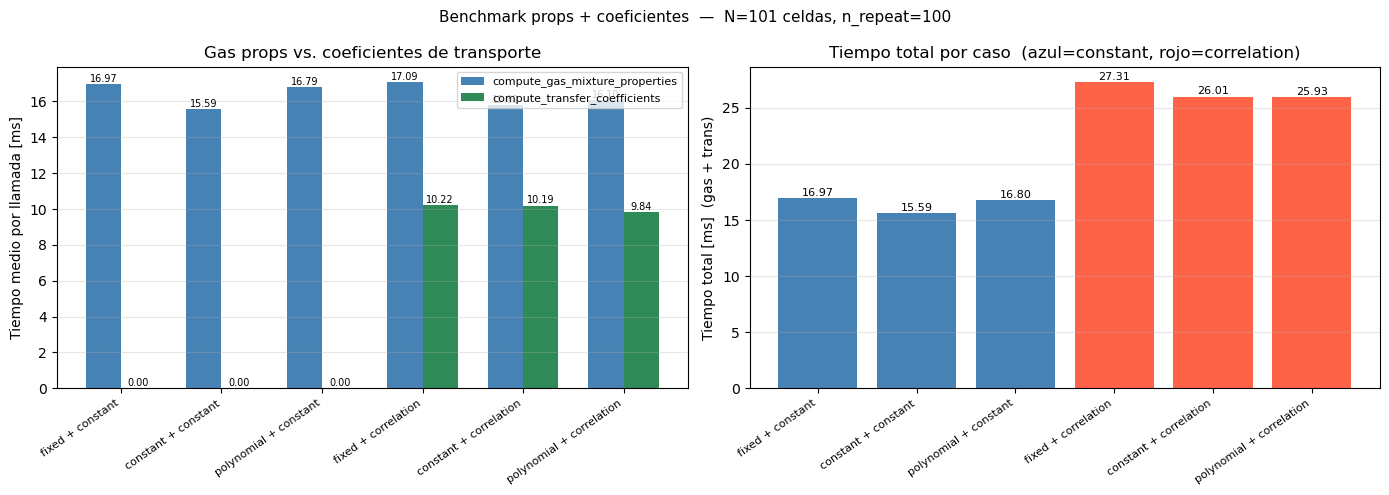

In [6]:
case_labels = df["Caso"].tolist()
x_pos  = np.arange(len(case_labels))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: gas props vs. transfer coeffs ──────────────────────────────
ax = axes[0]
b1 = ax.bar(x_pos - width/2, df["t_gas [ms]"],   width,
            label="compute_gas_mixture_properties", color="steelblue")
b2 = ax.bar(x_pos + width/2, df["t_trans [ms]"], width,
            label="compute_transfer_coefficients",  color="seagreen")
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.2f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x_pos)
ax.set_xticklabels(case_labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Tiempo medio por llamada [ms]")
ax.set_title("Gas props vs. coeficientes de transporte")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── Derecha: tiempo total por caso ───────────────────────────────────────
ax = axes[1]
colors = ["steelblue" if t == "constant" else "tomato"
          for t in df["transport_mode"]]
bars = ax.bar(x_pos, df["t_total [ms]"], color=colors)
for bar, val in zip(bars, df["t_total [ms]"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(case_labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Tiempo total [ms]  (gas + trans)")
ax.set_title("Tiempo total por caso  (azul=constant, rojo=correlation)")
ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Benchmark props + coeficientes  —  N={N} celdas, n_repeat={N_REPEAT}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 6. Verificación de consistencia física

Comprobación rápida de rangos en el caso `polynomial + correlation` (configuración más completa y recomendada en producción).

In [7]:
# Reejecutar el caso más completo para inspección
prop_gas_poly, trans_corr = build_configs("polynomial", "correlation")

gp = compute_gas_mixture_properties(
    P_Pa=P_Pa, Tg=Tg_arr, x=x_mat,
    prop_gas=prop_gas_poly, n_comp=nc, N=N,
)
tc = compute_transfer_coefficients(
    Tg=Tg_arr, Ts=Ts_arr, x=x_mat,
    gas_props=gp, u_rel=u_rel,
    prop_gas=prop_gas_poly, prop_lecho=prop_lecho,
    Di=Di, trans_config=trans_corr, n_comp=nc, N=N,
)

checks = {
    "MWmix [kg/mol]":     (gp["MWmix"].min(),      gp["MWmix"].max()),
    "rho [kg/m³]":        (gp["rho"].min(),         gp["rho"].max()),
    "mu [µPa·s]":         (gp["mu"].min()*1e6,      gp["mu"].max()*1e6),
    "k [mW/m/K]":         (gp["k"].min()*1e3,       gp["k"].max()*1e3),
    "Cp_mass [J/kg/K]":   (gp["Cp_mass"].min(),     gp["Cp_mass"].max()),
    "k_mtc CO2 [1/s]":    (tc["k_mtc"][0].min(),    tc["k_mtc"][0].max()),
    "k_mtc CH4 [1/s]":    (tc["k_mtc"][1].min(),    tc["k_mtc"][1].max()),
    "h_bed [W/m²/K]":     (tc["h_bed"].min(),       tc["h_bed"].max()),
    "h_wall [W/m²/K]":    (tc["h_wall"].min(),      tc["h_wall"].max()),
    "D_disp CO2 [cm²/s]": (tc["D_disp"][0].min()*1e4, tc["D_disp"][0].max()*1e4),
}

df_check = pd.DataFrame(
    [{"Magnitud": k, "mín": v[0], "máx": v[1]} for k, v in checks.items()]
).set_index("Magnitud")
pd.set_option("display.float_format", "{:.4g}".format)
display(df_check)

# Verificaciones de signo
assert np.all(gp["rho"]    > 0), "rho debe ser positiva"
assert np.all(gp["mu"]     > 0), "mu debe ser positiva"
assert np.all(tc["k_mtc"]  > 0), "k_mtc debe ser positivo"
assert np.all(tc["h_bed"]  > 0), "h_bed debe ser positivo"
assert np.all(tc["h_wall"] > 0), "h_wall debe ser positivo"
print("Verificación OK — todos los rangos son físicamente consistentes.")

,mín,máx
Magnitud,,
MWmix [kg/mol],0.02863,0.03142
rho [kg/m³],5.774,7.128
mu [µPa·s],13.61,14.8
k [mW/m/K],22.19,22.67
Cp_mass [J/kg/K],1185,1259
k_mtc CO2 [1/s],205.5,271.3
k_mtc CH4 [1/s],235.2,237.5
h_bed [W/m²/K],290.6,367.6
h_wall [W/m²/K],4.1,5.81


Verificación OK — todos los rangos son físicamente consistentes.
